# Tarea

In [5]:
#Cargamos las librerias necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from scipy.stats import ks_2samp

#Leemos el archivo CSV
df = pd.read_csv("ds_salaries.csv")

#Le quitamos los valores nulos
df_clean = df.dropna()

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 607 entries, 0 to 606
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Working_Year          595 non-null    float64
 1   Designation           600 non-null    object 
 2   Experience            607 non-null    object 
 3   Employment_Status     607 non-null    object 
 4   Employee_Location     607 non-null    object 
 5   Company_Size          607 non-null    object 
 6   Remote_Working_Ratio  607 non-null    int64  
 7   Salary_USD            597 non-null    float64
dtypes: float64(2), int64(1), object(5)
memory usage: 38.1+ KB


In [7]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 578 entries, 0 to 606
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Working_Year          578 non-null    float64
 1   Designation           578 non-null    object 
 2   Experience            578 non-null    object 
 3   Employment_Status     578 non-null    object 
 4   Employee_Location     578 non-null    object 
 5   Company_Size          578 non-null    object 
 6   Remote_Working_Ratio  578 non-null    int64  
 7   Salary_USD            578 non-null    float64
dtypes: float64(2), int64(1), object(5)
memory usage: 40.6+ KB


# Verificación de la columna 'Working_Year' después de eliminar los valores faltantes

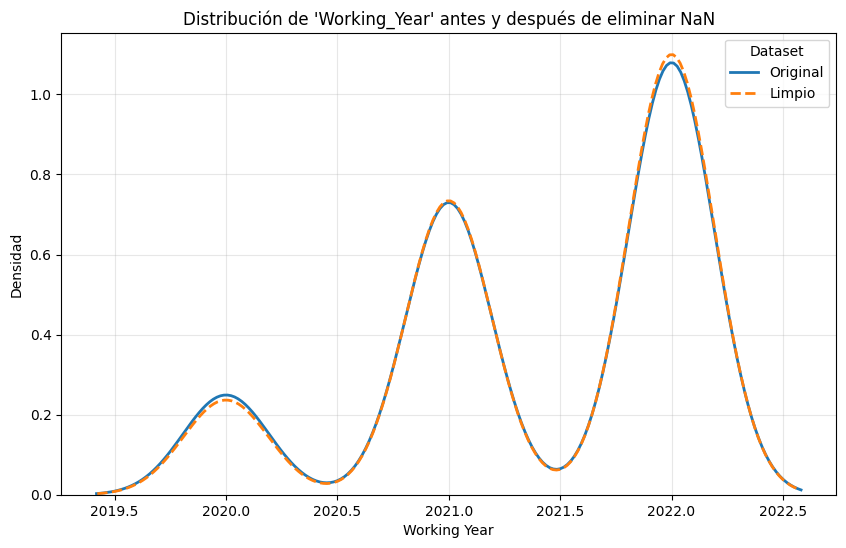

In [ ]:
import warnings

# Ignorar warnings
warnings.filterwarnings("ignore", category=FutureWarning)

# Crear gráfico de densidad
plt.figure(figsize=(10, 6))
sns.kdeplot(df['Working_Year'], label='Original', linewidth=2)
sns.kdeplot(df_clean['Working_Year'], label='Limpio', linewidth=2, linestyle='--')

plt.title("Distribución de 'Working_Year' antes y después de eliminar NaN")
plt.xlabel("Working Year")
plt.ylabel("Densidad")
plt.legend(title="Dataset")
plt.grid(alpha=0.3)
plt.show()

In [11]:
stat, p_value = ks_2samp(df['Working_Year'], df_clean['Working_Year'])

print("Prueba Kolmogorov-Smirnov (KS) para 'Working_Year' ")
print("Estadístico KS:", stat)
print("Valor p:", p_value)
if p_value < 0.05:
    print("✅ Hay diferencias significativas entre las dos distribuciones.")
else:
    print("❌ No hay evidencia significativa de que las distribuciones sean diferentes.")

Prueba Kolmogorov-Smirnov (KS) para 'Working_Year' 
Estadístico KS: 0.019769357495881382
Valor p: 0.9996434837828819
❌ No hay evidencia significativa de que las distribuciones sean diferentes.


# Verificación de la columna 'Designation' después de eliminar los valores faltantes

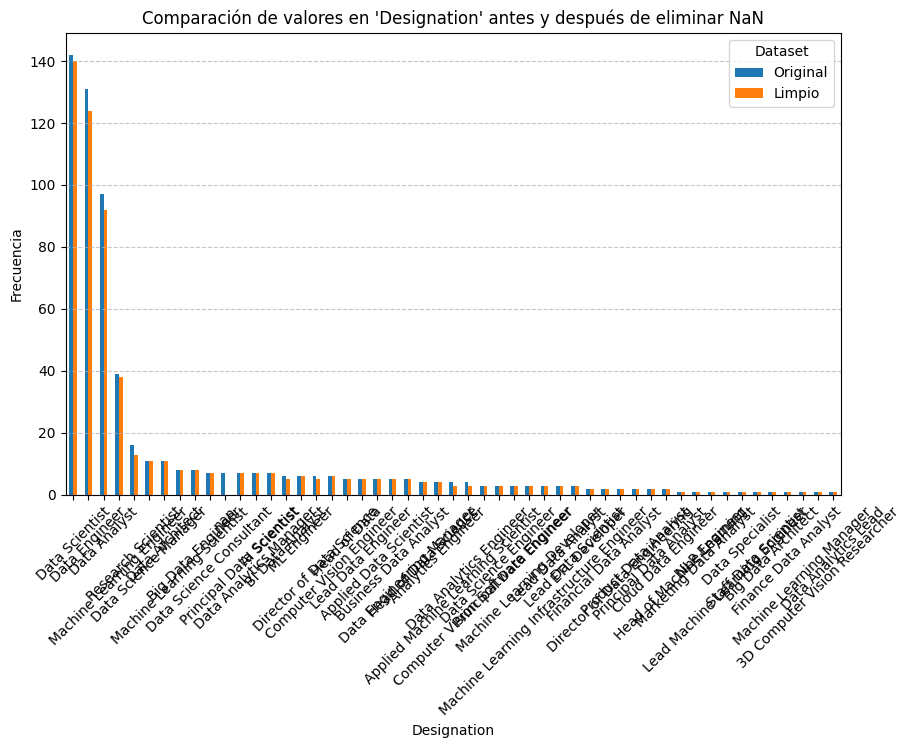

In [22]:
# Contar frecuencias en cada DataFrame
original_counts = df['Designation'].value_counts(dropna=False)
clean_counts = df_clean['Designation'].value_counts()

# Unir ambos conteos en un solo DataFrame
comparison = pd.concat(
    [original_counts.rename("Original"), clean_counts.rename("Limpio")],
    axis=1
).fillna(0)

# Crear gráfico de barras agrupado
comparison.plot(kind='bar', figsize=(10, 6))

plt.title("Comparación de valores en 'Designation' antes y después de eliminar NaN")
plt.xlabel("Designation")
plt.ylabel("Frecuencia")
plt.xticks(rotation=45)
plt.legend(title="Dataset")
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

In [24]:
# Alinear categorías para evitar errores
comparison_table = pd.concat([original_counts, clean_counts], axis=1, keys=['Original', 'Limpio']).fillna(0)

# Prueba chi-cuadrado
chi2, p, dof, expected = chi2_contingency(comparison_table.T)

# Mostrar resultados
print("Prueba Chi-cuadrado de homogeneidad")
print("Estadístico chi²:", chi2)
print("Grados de libertad:", dof)
print("Valor p:", p)
if p_value < 0.05:
    print("✅ Hay diferencias significativas entre las dos distribuciones.")
else:
    print("❌ No hay evidencia significativa de que las distribuciones sean diferentes.")

Prueba Chi-cuadrado de homogeneidad
Estadístico chi²: 7.424222476787089
Grados de libertad: 50
Valor p: 0.9999999999996807
❌ No hay evidencia significativa de que las distribuciones sean diferentes.


# Verificación de la columna 'Emplyment_Status' después de eliminar los valores faltantes

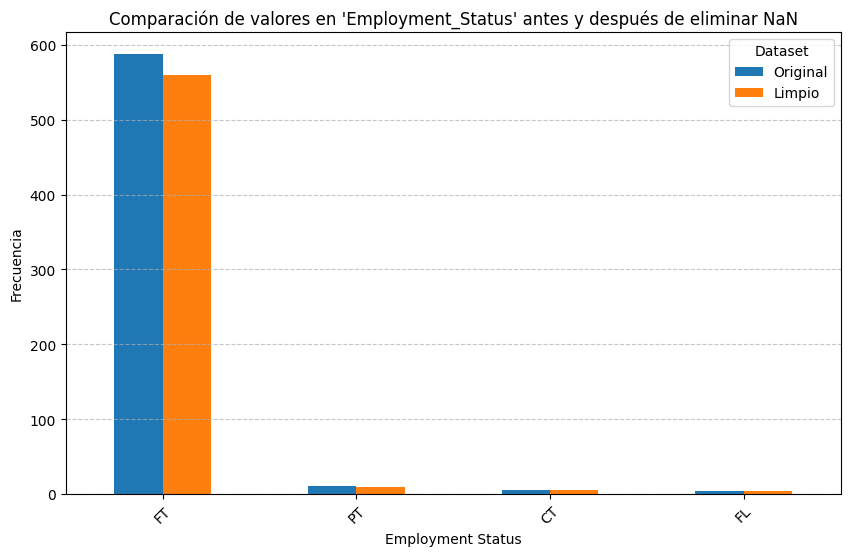

In [25]:
# Contar frecuencias en cada DataFrame
original_counts = df['Employment_Status'].value_counts(dropna=False)
clean_counts = df_clean['Employment_Status'].value_counts()

# Unir ambos conteos en un solo DataFrame
comparison = pd.concat(
    [original_counts.rename("Original"), clean_counts.rename("Limpio")],
    axis=1
).fillna(0)

# Crear gráfico de barras agrupado
comparison.plot(kind='bar', figsize=(10, 6))

plt.title("Comparación de valores en 'Employment_Status' antes y después de eliminar NaN")
plt.xlabel("Employment Status")
plt.ylabel("Frecuencia")
plt.xticks(rotation=45)
plt.legend(title="Dataset")
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

In [26]:
# Alinear categorías para evitar errores
comparison_table = pd.concat([original_counts, clean_counts], axis=1, keys=['Original', 'Limpio']).fillna(0)

# Prueba chi-cuadrado
chi2, p, dof, expected = chi2_contingency(comparison_table.T)

# Mostrar resultados
print("Prueba Chi-cuadrado de homogeneidad")
print("Estadístico chi²:", chi2)
print("Grados de libertad:", dof)
print("Valor p:", p)
if p_value < 0.05:
    print("✅ Hay diferencias significativas entre las dos distribuciones.")
else:
    print("❌ No hay evidencia significativa de que las distribuciones sean diferentes.")

Prueba Chi-cuadrado de homogeneidad
Estadístico chi²: 0.0258692601430804
Grados de libertad: 3
Valor p: 0.9989019380364029
❌ No hay evidencia significativa de que las distribuciones sean diferentes.


# Verificación de la columna 'Employee_Location' después de eliminar los valores faltantes

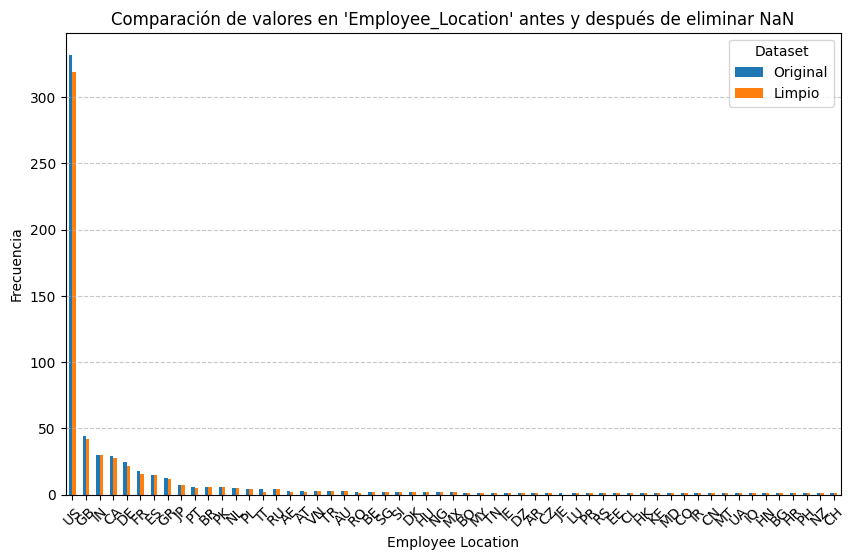

In [27]:
# Contar frecuencias en cada DataFrame
original_counts = df['Employee_Location'].value_counts(dropna=False)
clean_counts = df_clean['Employee_Location'].value_counts()

# Unir ambos conteos en un solo DataFrame
comparison = pd.concat(
    [original_counts.rename("Original"), clean_counts.rename("Limpio")],
    axis=1
).fillna(0)

# Crear gráfico de barras agrupado
comparison.plot(kind='bar', figsize=(10, 6))

plt.title("Comparación de valores en 'Employee_Location' antes y después de eliminar NaN")
plt.xlabel("Employee Location")
plt.ylabel("Frecuencia")
plt.xticks(rotation=45)
plt.legend(title="Dataset")
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

In [28]:
# Alinear categorías para evitar errores
comparison_table = pd.concat([original_counts, clean_counts], axis=1, keys=['Original', 'Limpio']).fillna(0)

# Prueba chi-cuadrado
chi2, p, dof, expected = chi2_contingency(comparison_table.T)

# Mostrar resultados
print("Prueba Chi-cuadrado de homogeneidad")
print("Estadístico chi²:", chi2)
print("Grados de libertad:", dof)
print("Valor p:", p)
if p_value < 0.05:
    print("✅ Hay diferencias significativas entre las dos distribuciones.")
else:
    print("❌ No hay evidencia significativa de que las distribuciones sean diferentes.")

Prueba Chi-cuadrado de homogeneidad
Estadístico chi²: 2.455467568476613
Grados de libertad: 56
Valor p: 1.0
❌ No hay evidencia significativa de que las distribuciones sean diferentes.


# Verificación de la columna 'Company_Size' después de eliminar los valores faltantes

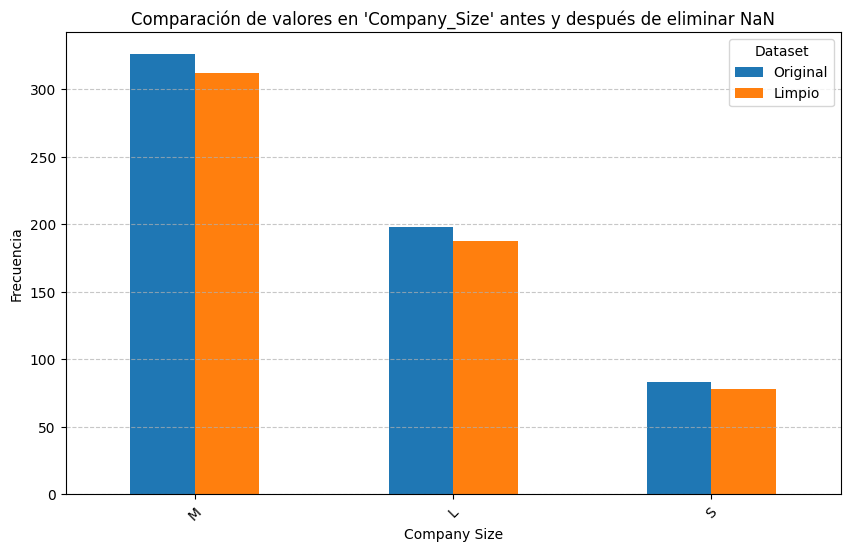

In [30]:
# Contar frecuencias en cada DataFrame
original_counts = df['Company_Size'].value_counts(dropna=False)
clean_counts = df_clean['Company_Size'].value_counts()

# Unir ambos conteos en un solo DataFrame
comparison = pd.concat(
    [original_counts.rename("Original"), clean_counts.rename("Limpio")],
    axis=1
).fillna(0)

# Crear gráfico de barras agrupado
comparison.plot(kind='bar', figsize=(10, 6))

plt.title("Comparación de valores en 'Company_Size' antes y después de eliminar NaN")
plt.xlabel("Company Size")
plt.ylabel("Frecuencia")
plt.xticks(rotation=45)
plt.legend(title="Dataset")
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

In [34]:
# Alinear categorías para evitar errores
comparison_table = pd.concat([original_counts, clean_counts], axis=1, keys=['Original', 'Limpio']).fillna(0)

# Prueba chi-cuadrado
chi2, p, dof, expected = chi2_contingency(comparison_table.T)

# Mostrar resultados
print("Prueba Chi-cuadrado de homogeneidad")
print("Estadístico chi²:", chi2)
print("Grados de libertad:", dof)
print("Valor p:", p)
if p_value < 0.05:
    print("✅ Hay diferencias significativas entre las dos distribuciones.")
else:
    print("❌ No hay evidencia significativa de que las distribuciones sean diferentes.")

Prueba Chi-cuadrado de homogeneidad
Estadístico chi²: 0.011859353264442794
Grados de libertad: 2
Valor p: 0.9940878692027539
❌ No hay evidencia significativa de que las distribuciones sean diferentes.


# Verificación de la columna 'Salary_USD' después de eliminar los valores faltantes

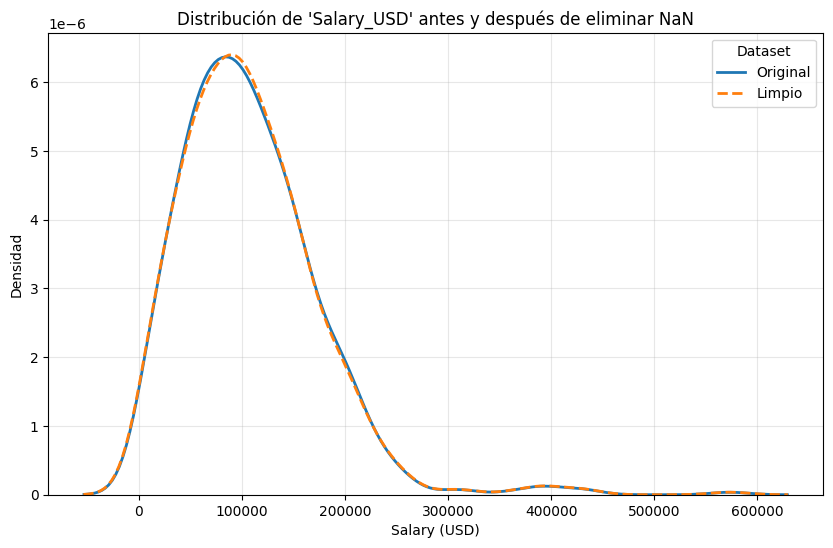

In [35]:
import warnings

# Ignorar warnings
warnings.filterwarnings("ignore", category=FutureWarning)

# Crear gráfico de densidad
plt.figure(figsize=(10, 6))
sns.kdeplot(df['Salary_USD'], label='Original', linewidth=2)
sns.kdeplot(df_clean['Salary_USD'], label='Limpio', linewidth=2, linestyle='--')

plt.title("Distribución de 'Salary_USD' antes y después de eliminar NaN")
plt.xlabel("Salary (USD)")
plt.ylabel("Densidad")
plt.legend(title="Dataset")
plt.grid(alpha=0.3)
plt.show()

In [36]:
stat, p_value = ks_2samp(df['Salary_USD'], df_clean['Salary_USD'])

print("Prueba Kolmogorov-Smirnov (KS) para 'Salary_USD' ")
print("Estadístico KS:", stat)
print("Valor p:", p_value)
if p_value < 0.05:
    print("✅ Hay diferencias significativas entre las dos distribuciones.")
else:
    print("❌ No hay evidencia significativa de que las distribuciones sean diferentes.")

Prueba Kolmogorov-Smirnov (KS) para 'Salary_USD' 
Estadístico KS: 0.01769152277637482
Valor p: 0.9999626091012846
❌ No hay evidencia significativa de que las distribuciones sean diferentes.
